<a href="https://colab.research.google.com/github/olaqarawani/Data-Science/blob/main/Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ola Baninemra 1210967

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv("C:\\Users\\sef\\Desktop\\Data Science\\palestine_food_prices.csv")
df = pd.DataFrame(data)
df

,date,region,city,market,latitude,longitude,category,commodity,unit,priceflag,pricetype,currency,price,usdprice
0,1/15/2007,Gaza Strip,Gaza,Gaza,31.506077,34.462746,cereals and tubers,Bread,KG,actual,Retail,ILS,2.00,0.4739
1,1/15/2007,Gaza Strip,Gaza,Gaza,31.506077,34.462746,cereals and tubers,Rice (long grain),KG,actual,Retail,ILS,13.00,3.0806
2,1/15/2007,Gaza Strip,Gaza,Gaza,31.506077,34.462746,cereals and tubers,"Rice (short grain, low quality, local)",KG,actual,Retail,ILS,4.00,0.9479
3,1/15/2007,Gaza Strip,Gaza,Gaza,31.506077,34.462746,cereals and tubers,Semolina,KG,actual,Retail,ILS,2.75,0.6517
4,1/15/2007,Gaza Strip,Gaza,Gaza,31.506077,34.462746,cereals and tubers,Wheat,KG,actual,Retail,ILS,2.65,0.6280
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26413,7/15/2024,West Bank,Ramallah and Albireh,West Bank,31.973144,35.329920,vegetables and fruits,Cauliflower,KG,actual,Retail,ILS,5.89,1.6316
26414,7/15/2024,West Bank,Ramallah and Albireh,West Bank,31.973144,35.329920,vegetables and fruits,Cucumbers (greenhouse),KG,actual,Retail,ILS,4.52,1.2521
26415,7/15/2024,West Bank,Ramallah and Albireh,West Bank,31.973144,35.329920,vegetables and fruits,Eggplants (large),KG,actual,Retail,ILS,3.65,1.0111
26416,7/15/2024,West Bank,Ramallah and Albireh,West Bank,31.973144,35.329920,vegetables and fruits,"Onions (dry, local)",KG,actual,Retail,ILS,4.06,1.1247


In [ ]:
data2 = pd.read_excel("C:\\Users\\sef\\Desktop\\Data Science\\palestine_political_events.xlsx")
df2 = pd.DataFrame(data2)
df2

,Country,Region,City,ISO3,Month,Year,Number of Events,Number of Fatalities
0,Palestine,Gaza Strip,Gaza City,PSE,January,2016,6,0
1,Palestine,Gaza Strip,North Gaza,PSE,January,2016,4,1
2,Palestine,West Bank,Salfit,PSE,January,2016,3,2
3,Palestine,West Bank,Al Quds,PSE,January,2016,16,1
4,Palestine,Gaza Strip,Rafah,PSE,January,2016,1,0
...,...,...,...,...,...,...,...,...
1691,Palestine,West Bank,Tulkarm,PSE,October,2024,36,23
1692,Palestine,West Bank,Bethlehem,PSE,October,2024,36,0
1693,Palestine,West Bank,Jericho,PSE,October,2024,8,1
1694,Palestine,West Bank,Qalqilya,PSE,October,2024,16,0


In [ ]:
def unified_price(row):

    if 'KG' in row['unit']:
        return row['price']
    elif 'G' in row['unit']:
        return row['price']/1000
    elif 'L' in row['unit']:
        return row['price']
    elif 'Cubic meter' in row['unit']:
        return row['price'] * 1000

    return 'price'

df['unified_price'] = df.apply(unified_price, axis=1)
df



,date,region,city,market,latitude,longitude,category,commodity,unit,priceflag,pricetype,currency,price,usdprice,unified_price
0,1/15/2007,Gaza Strip,Gaza,Gaza,31.506077,34.462746,cereals and tubers,Bread,KG,actual,Retail,ILS,2.00,0.4739,2.00
1,1/15/2007,Gaza Strip,Gaza,Gaza,31.506077,34.462746,cereals and tubers,Rice (long grain),KG,actual,Retail,ILS,13.00,3.0806,13.00
2,1/15/2007,Gaza Strip,Gaza,Gaza,31.506077,34.462746,cereals and tubers,"Rice (short grain, low quality, local)",KG,actual,Retail,ILS,4.00,0.9479,4.00
3,1/15/2007,Gaza Strip,Gaza,Gaza,31.506077,34.462746,cereals and tubers,Semolina,KG,actual,Retail,ILS,2.75,0.6517,2.75
4,1/15/2007,Gaza Strip,Gaza,Gaza,31.506077,34.462746,cereals and tubers,Wheat,KG,actual,Retail,ILS,2.65,0.6280,2.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26413,7/15/2024,West Bank,Ramallah and Albireh,West Bank,31.973144,35.329920,vegetables and fruits,Cauliflower,KG,actual,Retail,ILS,5.89,1.6316,5.89
26414,7/15/2024,West Bank,Ramallah and Albireh,West Bank,31.973144,35.329920,vegetables and fruits,Cucumbers (greenhouse),KG,actual,Retail,ILS,4.52,1.2521,4.52
26415,7/15/2024,West Bank,Ramallah and Albireh,West Bank,31.973144,35.329920,vegetables and fruits,Eggplants (large),KG,actual,Retail,ILS,3.65,1.0111,3.65
26416,7/15/2024,West Bank,Ramallah and Albireh,West Bank,31.973144,35.329920,vegetables and fruits,"Onions (dry, local)",KG,actual,Retail,ILS,4.06,1.1247,4.06


## Question 1): When did the food price monitoring begin in Gaza and West Bank?


In [ ]:
df['date']=pd.to_datetime(df['date'])

begingz = df[df['region'] =='Gaza Strip']
begingz = begingz.sort_values(by= "date", ascending=True)
begingz.head(1)

,date,region,city,market,latitude,longitude,category,commodity,unit,priceflag,pricetype,currency,price,usdprice,unified_price
0,2007-01-15,Gaza Strip,Gaza,Gaza,31.506077,34.462746,cereals and tubers,Bread,KG,actual,Retail,ILS,2.0,0.4739,2.0


**in this part I have filtered all the records in Gaza Strip only, then  I have sorted them by date (to know when did the price food monitoring begin) and finally I used df.head(1) to display the first date.**

**SO in Gaza Strip the price food monitoring begin in 15/01/2007.**


In [ ]:
beginwb = df[df['region'] =='West Bank']
beginwb = beginwb.sort_values(by= "date",ascending = True)
beginwb.head(1)

,date,region,city,market,latitude,longitude,category,commodity,unit,priceflag,pricetype,currency,price,usdprice,unified_price
907,2014-05-15,West Bank,Bethlehem,Bethlehem,31.711758,35.202435,cereals and tubers,Bread,KG,actual,Retail,ILS,4.0,1.1561,4.0


**in this part I did the same thing as the previous one, I have filtered all the records in West Bank only, then  I have sorted them by date (to know when did the price food monitoring begin) and finally I used df.head(1) to display the first date.**

**SO in the West Bank the price food monitoring begin in 15/05/2014.**


## Question 2): Compare the average price of the "meat, fish and eggs" category between Gaza and West Bank? Interpret the results.

In [ ]:
categoryGaza = df[(df['category'] == 'meat, fish and eggs') & (df['region'] == 'Gaza Strip')]
avgGaza= categoryGaza['unified_price'].mean()
avgGaza

26.45288987435329

In [ ]:
categoryWB =  df[(df['category'] == 'meat, fish and eggs') & (df['region'] == 'West Bank')]
avgWB= categoryWB['unified_price'].mean()
avgWB

32.687324332617365

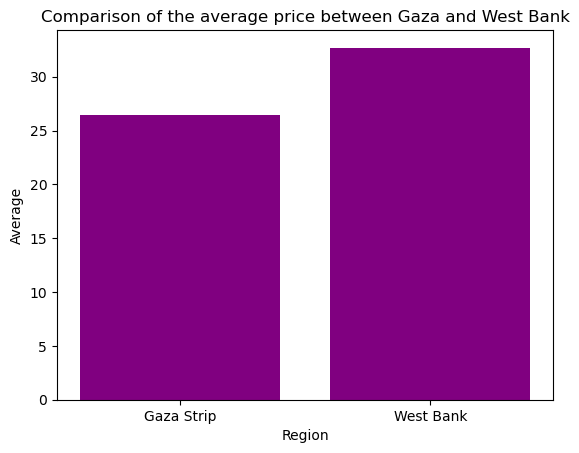

In [ ]:
cities = ['Gaza Strip', 'West Bank']
avg = [avgGaza ,avgWB]
plt.bar(cities, avg,color ='purple')
plt.title("Comparison of the average price between Gaza and West Bank")
plt.xlabel("Region")
plt.ylabel("Average")

plt.show()

**so from the output and from the Bar Plot we notice that the average price of the "meat, fish and eggs" category in West Bank is larger than Gaza Strip.**

## Question 3) : Which commodities have experienced the highest price volatility (extreme changes in price) over time? Interpret the results.

In [ ]:
volatilities = df[['commodity' ,'price']]
volatilities.groupby ('commodity')['price'].std().sort_values(ascending=False).head()

commodity
Wheat flour (locally processed)    139.885060
Wheat flour                         55.270885
Meat (goat, with bones)             14.946909
Fuel (petrol-gasoline)              13.055572
Meat (beef)                         12.053133
Name: price, dtype: float64

**I found the standard deviation for the prices, and the one with the highest standard deviation is the commodity that has experienced the highest price volatility.
from the output Wheat flour (locally processed) have experienced the highest price volatility then Wheat flour, then Meat (goat, with bones)**                        


## Question 4): Compare the total number of fatalities between different years. Is it increasing or decreasing? Interpret the results.

In [ ]:
fatalities = df2.groupby('Year')['Number of Fatalities'].sum()
fatalities

Year
2016      164
2017      108
2018      199
2019      146
2020       43
2021      312
2022      216
2023    22607
2024    24873
Name: Number of Fatalities, dtype: int64

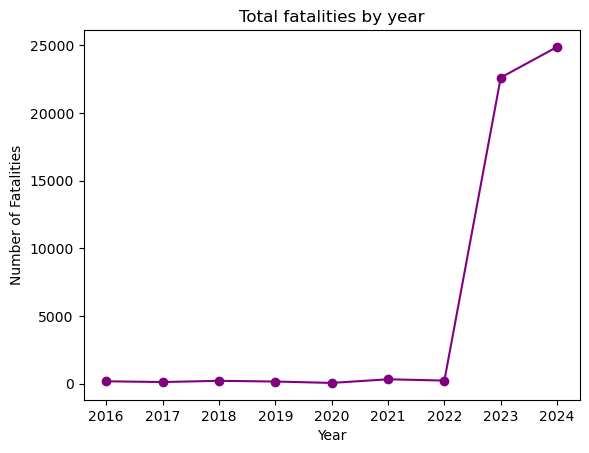

In [ ]:
fatalities.plot(marker = 'o', color = 'purple')
plt.title("Total fatalities by year")
plt.xlabel("Year")
plt.ylabel("Number of Fatalities")
plt.show()

**From this result we can notice that the number of fatalities is not really increasing from year 2016 to 2022, but after the year 2022 we can notice that there is a huge increasing in number of fatalities.**

# Question 5): Do the prices affected by the number of violent events happened in the same month? Interpret the results.

In [ ]:
df['date']=pd.to_datetime(df['date'])
df['Month'] = df['date'].dt.month_name()
df['Year'] = df['date'].dt.year

price_data = df.groupby(['Year', 'Month']).agg({'price': 'mean'})
events_data = df2.groupby(['Year', 'Month']).agg({'Number of Events': 'sum'})

merged_data = pd.merge(price_data, events_data, on=['Year', 'Month'], how='inner')
merged_data

price  Number of Events
Year Month                                
2016 April     22.627132                54
     August    23.179621                54
     December  22.795896                40
     February  22.877405                83
     January   21.795303                92
...                  ...               ...
2024 January   48.105806              1856
     July      36.106935              1595
     June      36.086935              1409
     March     53.553065              1649
     May       27.101290              1743

[103 rows x 2 columns]

In [ ]:
correlation = merged_data['Number of Events'].corr(merged_data['price'])
correlation

0.7634024223716958

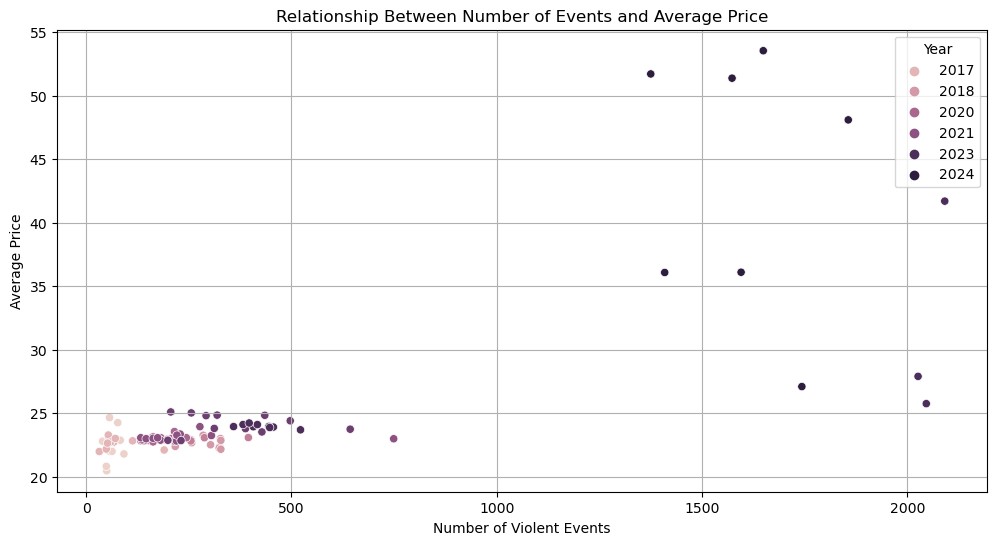

In [ ]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=merged_data, x='Number of Events', y='price', hue='Year')
plt.title('Relationship Between Number of Events and Average Price')
plt.xlabel('Number of Violent Events')
plt.ylabel('Average Price')
plt.grid(True)
plt.show()

**From the correlation  I have found (0.76) it says that there is a positive relation between violent events and prices in the same months, in the months when violent events happens more, we notice that the price increases.**